This runs a series of increasing frequency of positive versus negative interactions, and then plots that versus the proportion of significant positive and negative associations.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx

import metaCommunityMx
import metrics_and_plotting
import run_cooccurrence
reload(metaCommunityMx)
reload(metrics_and_plotting)
reload(run_cooccurrence)

import pickle, os
os.makedirs('figure_data', exist_ok=True)

<module 'run_cooccurrence' from '/Users/fionacallahan/Documents/Nielsen_lab/TheoryCoOccur/run_cooccurrence.py'>

In [12]:
# for random matrix
# interactFactor = 1/5 # 1/3 1/5 1/10
# interactStren = alpha * interactFactor
nSpec = 100
pInteract = 0.05

# parms for GLV sim
#alpha = 0.001
#Use below for variable carrying capacities. 0.001 = 1000; going from 500 to 1500 is 0.0007 to 0.002
alpha = np.random.uniform(low = 0.0007, high = 0.002, size = nSpec)
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))
nreps = 10

In [ ]:
interactFactorL = np.array([1/3, 1/5, 1/10])
# alpha = np.array([1, 2, 3])
# for i in range(len(np.array)):
#     alphalist

Run simulation for different proportions of positive interactions

0


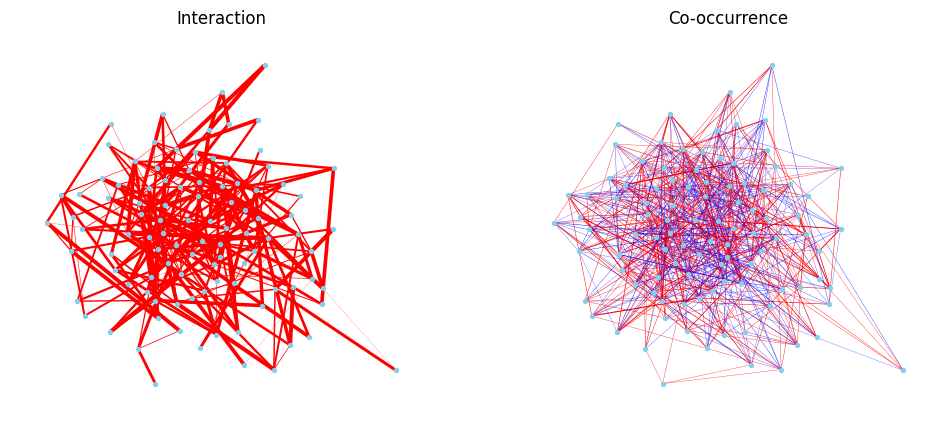

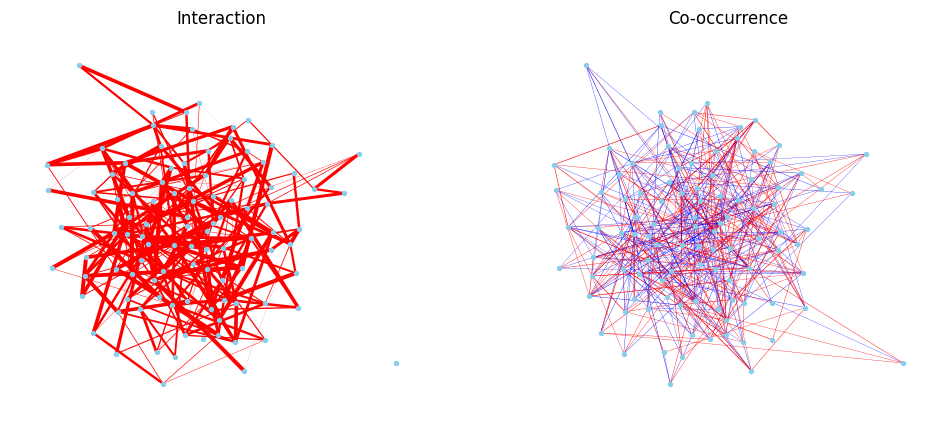

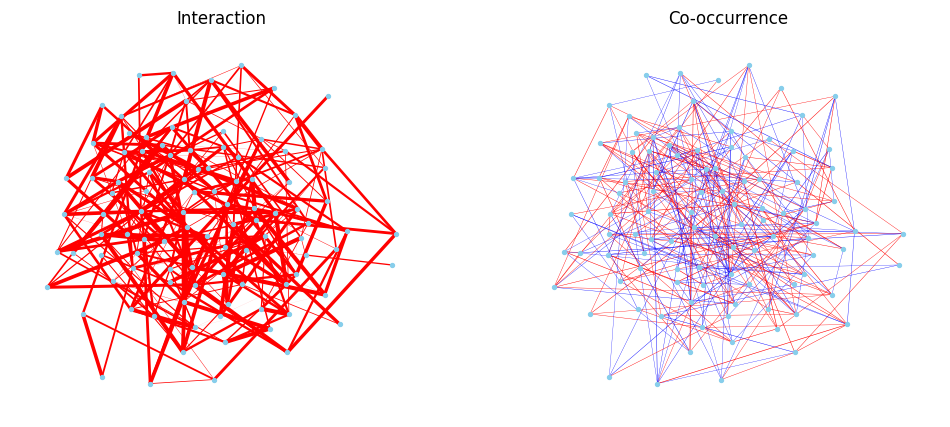

0.1
0.2
0.3
0.4
0.5
0.6


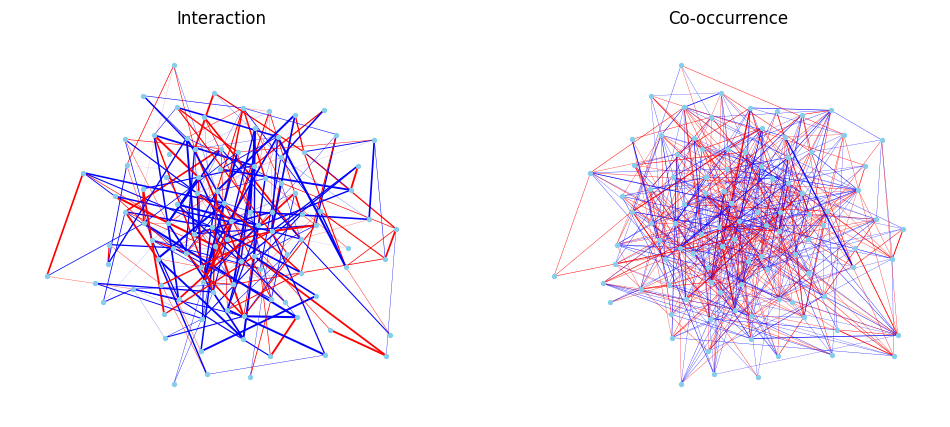

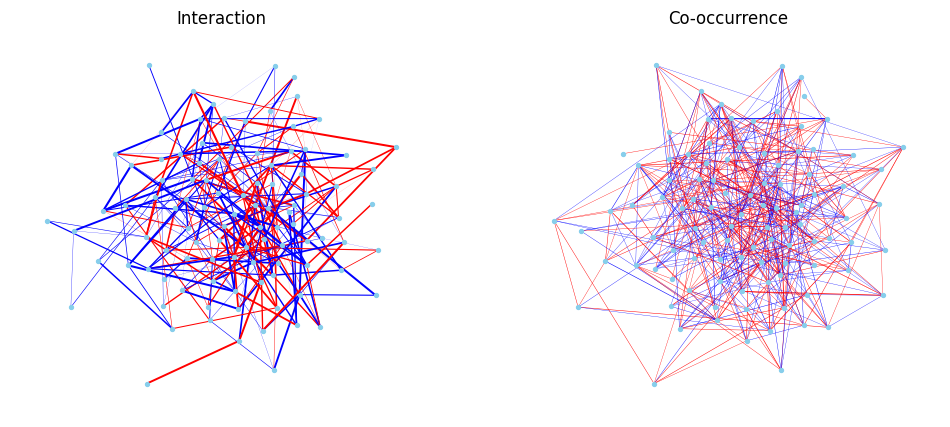

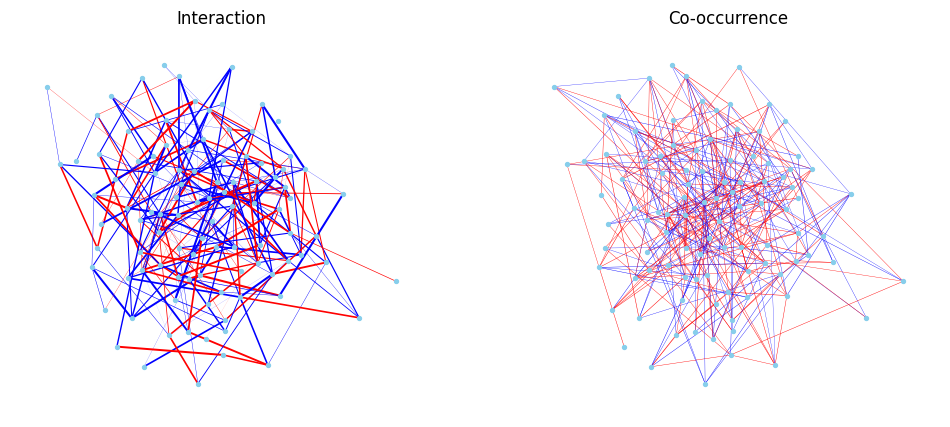

0.7
0.8
0.9
0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0
System did not converge. Trying with max_step=1.0
System did not converge. Trying with max_step=1.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0
System did not converge. Trying with max_step=1.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0
System did not converge. Trying with max_step=1.0
System did not converge. Trying with max_step=1.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0
System did not converge. Trying with max_step=1.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9


In [13]:
# zeroMx = np.zeros(shape = (nSpec, nSpec))
interactFactorL = np.array([1/3, 1/5, 1/10])

#interactStrenL = alpha * interactFactorL
pPosL = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9] # if we go over 0.6 we start to have convergence issues and other warnings
lower_cutoff, upper_cutoff = run_cooccurrence.get_null_cutoff(nSpec = nSpec, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, pval_alpha = 0.05)

totalCoocEdge = np.zeros(shape = (len(pPosL), len(interactFactorL), nreps))
totalPosCoocEdge = np.zeros(shape = (len(pPosL), len(interactFactorL), nreps))
totalInteractEdge = np.zeros(shape = (len(pPosL), len(interactFactorL), nreps))
totalPosInteractEdge = np.zeros(shape = (len(pPosL), len(interactFactorL), nreps))

for iii in range(nreps):
    for i in range(len(pPosL)):
        pPositive = pPosL[i]
        print(pPositive)
        for j in range(len(interactFactorL)):
            interactStren = np.mean(alpha)*interactFactorL[j]

            if pPositive > 0.6 and interactFactorL[j] > 1/5:
                totalCoocEdge[i,j, iii] = None
                totalPosCoocEdge[i,j, iii] = None

                totalInteractEdge[i,j, iii] = None
                totalPosInteractEdge[i,j, iii] = None
            else:
                if pPositive in [0, 0.6] and iii == 0:
                    plotNet = True
                else:
                    plotNet = False

                # make new interaction mx with the same total interaction proportion but a different proporion of positive interacitons
                randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

                # run sim to get coocurrence network
                network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = [lower_cutoff, upper_cutoff], alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, plotNetworks = plotNet)
                G_rand_inter = nx.from_numpy_array(randMx != 0)

                # save stats
                totalCoocEdge[i,j, iii] = sum(sum(network_rand != 0))
                totalPosCoocEdge[i,j, iii] = sum(sum(network_rand > 0))

                totalInteractEdge[i,j, iii] = sum(sum(randMx != 0))
                totalPosInteractEdge[i,j, iii] = sum(sum(randMx > 0))

pPosCoocL = totalPosCoocEdge / totalCoocEdge
pPosInteractL = totalPosInteractEdge / totalInteractEdge


In [14]:
print(np.round(pPosCoocL, 2))
print(np.round(pPosInteractL, 2))

[[[0.43 0.45 0.44 0.44 0.44 0.45 0.44 0.43 0.45 0.46]
  [0.45 0.41 0.42 0.42 0.43 0.45 0.44 0.4  0.45 0.42]
  [0.46 0.44 0.48 0.46 0.5  0.48 0.48 0.49 0.47 0.49]]

 [[0.44 0.42 0.5  0.47 0.46 0.44 0.45 0.44 0.46 0.48]
  [0.41 0.43 0.44 0.44 0.43 0.43 0.45 0.44 0.42 0.46]
  [0.48 0.51 0.45 0.47 0.44 0.46 0.5  0.52 0.49 0.48]]

 [[0.49 0.48 0.49 0.5  0.46 0.45 0.45 0.46 0.48 0.46]
  [0.46 0.48 0.47 0.44 0.44 0.46 0.44 0.47 0.46 0.42]
  [0.48 0.49 0.48 0.49 0.44 0.5  0.44 0.5  0.48 0.47]]

 [[0.48 0.48 0.5  0.52 0.51 0.5  0.48 0.46 0.5  0.49]
  [0.46 0.46 0.46 0.48 0.48 0.48 0.47 0.46 0.49 0.44]
  [0.47 0.49 0.45 0.47 0.51 0.49 0.46 0.49 0.49 0.51]]

 [[0.5  0.53 0.53 0.5  0.52 0.5  0.52 0.49 0.5  0.52]
  [0.5  0.5  0.48 0.46 0.48 0.49 0.48 0.49 0.51 0.48]
  [0.46 0.48 0.51 0.47 0.49 0.48 0.49 0.52 0.48 0.48]]

 [[0.54 0.51 0.51 0.52 0.51 0.52 0.54 0.51 0.51 0.53]
  [0.47 0.48 0.49 0.48 0.5  0.49 0.52 0.51 0.52 0.47]
  [0.54 0.46 0.45 0.49 0.5  0.51 0.49 0.48 0.48 0.51]]

 [[0.53 0.54 0.5

/var/folders/61/s5tv_93n0jl0_fpk6r7k4pvc0000gn/T/ipykernel_79957/3308227759.py:2: RuntimeWarning: Mean of empty slice
  pPosCoocL_mean = np.nanmean(pPosCoocL, axis=2)
/var/folders/61/s5tv_93n0jl0_fpk6r7k4pvc0000gn/T/ipykernel_79957/3308227759.py:3: RuntimeWarning: Mean of empty slice
  pPosInteractL_mean = np.nanmean(pPosInteractL, axis=2)
/Users/fionacallahan/Documents/Nielsen_lab/TheoryCoOccur/networks_claire/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


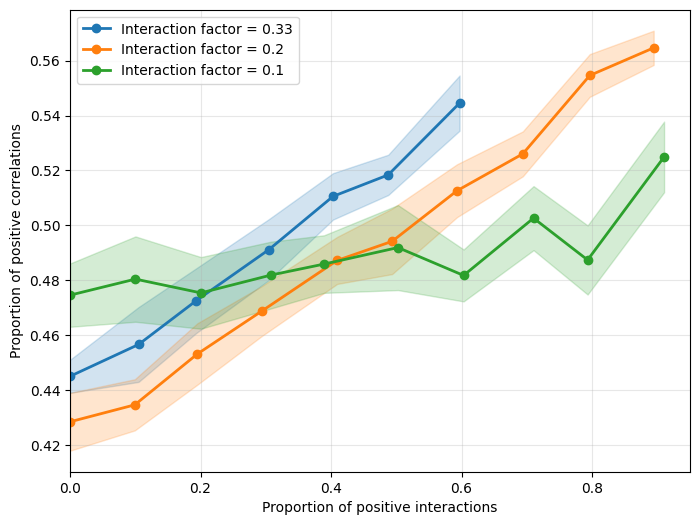

In [ ]:
# Average across replicates (third dimension) and compute statistics for 95% CI
pPosCoocL_mean = np.nanmean(pPosCoocL, axis=2)
pPosInteractL_mean = np.nanmean(pPosInteractL, axis=2)

# Calculate 95% confidence interval using standard error
# For 95% CI with normal distribution, use 1.96 * SEM
pPosCoocL_sem = np.nanstd(pPosCoocL, axis=2, ddof=1) / np.sqrt(np.sum(~np.isnan(pPosCoocL), axis=2))
pPosInteractL_sem = np.nanstd(pPosInteractL, axis=2, ddof=1) / np.sqrt(np.sum(~np.isnan(pPosInteractL), axis=2))

# 95% CI bounds
pPosCoocL_ci_lower = pPosCoocL_mean - 1.96 * pPosCoocL_sem
pPosCoocL_ci_upper = pPosCoocL_mean + 1.96 * pPosCoocL_sem
pPosInteractL_ci_lower = pPosInteractL_mean - 1.96 * pPosInteractL_sem
pPosInteractL_ci_upper = pPosInteractL_mean + 1.96 * pPosInteractL_sem

with open('figure_data/fit_pos_freq.pkl', 'wb') as f:
    pickle.dump({
        'pPosCoocL_mean': pPosCoocL_mean,
        'pPosInteractL_mean': pPosInteractL_mean,
        'pPosCoocL_ci_lower': pPosCoocL_ci_lower,
        'pPosCoocL_ci_upper': pPosCoocL_ci_upper,
        'interactFactorL': interactFactorL,
        'pPosL': pPosL,
    }, f)

plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Default matplotlib colors

for ii in range(len(interactFactorL)):
    # Plot the line
    plt.plot(pPosInteractL_mean[:,ii], pPosCoocL_mean[:,ii],
             'o-', markersize=6, lw=2, color=colors[ii], 
             label=f"Interaction factor = {np.round(interactFactorL[ii], 2)}")
    
    # Add shaded 95% confidence interval
    plt.fill_between(pPosInteractL_mean[:,ii], 
                     pPosCoocL_ci_lower[:,ii], 
                     pPosCoocL_ci_upper[:,ii],
                     alpha=0.2, color=colors[ii])

plt.xlim(0, max(pPosL) + 0.05)
plt.xlabel('Proportion of positive interactions')
plt.ylabel('Proportion of positive correlations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Now we are looking at specific interaction types

generateInteractionTypeMx(maxInteractionStrength, nSpecies, interactionTypeFreq)
interactionTypeFromMx(interactMx)

interactionTypeFreq (numpy array of shape (6)): Frequency of types of interactions (+/+, -/-, +/-, +/0, -/0, 0/0)

In [ ]:
# reload(metaCommunityMx)

# # for random matrix
# interactFactor = 1/10
# interactStren = alpha * interactFactor ##NOTE made this lower so we don't have blowups!
# nSpec = 100
# pInteract = 0.4 

# # parms for GLV sim
# alpha = 0.001 
# samplesize = int(0.5 * nSpec) # number of species to sample
# numtrials = 500
# b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

# # columns are frequency vectors
# interactionTypeFreqArray = np.array(np.random.uniform(low = 0, high = 1, size = (6,100)))
# interactionTypeFreqArray = interactionTypeFreqArray / sum(interactionTypeFreqArray)

# cutoffL = [0.05, 0.1, 0.15, 0.2]

# edgeTypes_interaction = np.zeros(shape = (6, interactionTypeFreqArray.shape[1], len(cutoffL)))
# edgeTypes_cooc = np.zeros(shape = (6, interactionTypeFreqArray.shape[1], len(cutoffL)))

# for i in range(interactionTypeFreqArray.shape[1]):
#     interactionTypeFreq = interactionTypeFreqArray[:,i]
#     print(interactionTypeFreq)
#     print(interactionTypeFreq.shape)
#     for j in range(len(cutoffL)):
#         cutoff = cutoffL[j]
#         plotNet = False

#         # make new interaction mx with the specified frequencies of interaction types
#         randMx = metaCommunityMx.generateInteractionTypeMx(maxInteractionStrength = interactStren, nSpecies = nSpec, interactionTypeFreq = interactionTypeFreq)

#         # run sim to get coocurrence network
#         network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, plotNetworks = plotNet)

#         # get actual frequencies
#         edgeTypes_interaction[:,i,j] = metaCommunityMx.interactionTypeFromMx(randMx)
#         edgeTypes_cooc[:,i,j]  = metaCommunityMx.interactionTypeFromMx(network_rand)


# diff = edgeTypes_interaction - edgeTypes_cooc

[0.27393465 0.08152115 0.15916463 0.11923876 0.24977845 0.11636235]
(6,)


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 2 with shape (100,).

In [ ]:
# get a null distribution of differences in frequencies when they are random

# print(diff.shape)
# nullFreqArray1 = np.array(np.random.uniform(low = 0, high = 1, size = (6,100)))
# nullFreqArray1 = nullFreqArray1 / sum(nullFreqArray1)
# nullFreqArray2 = np.array(np.random.uniform(low = 0, high = 1, size = (6,100)))
# nullFreqArray2 = nullFreqArray2 / sum(nullFreqArray2)

# nullDiff = nullFreqArray1 - nullFreqArray2
# print(nullDiff.shape)

# with open('figure_data/fit_freq_diff.pkl', 'wb') as f:
#     pickle.dump({'diff': diff, 'nullDiff': nullDiff, 'cutoffL': cutoffL}, f)

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[0,:], label = "Null +/+")
# for i in range(len(cutoffL)):
#     plt.hist(diff[0,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[1,:], label = "Null -/-")
# for i in range(len(cutoffL)):
#     plt.hist(diff[1,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[2,:], label = "Null +/-")
# for i in range(len(cutoffL)):
#     plt.hist(diff[2,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[3,:], label = "Null +/0")
# for i in range(len(cutoffL)):
#     plt.hist(diff[3,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[4,:], label = "Null -/0")
# for i in range(len(cutoffL)):
#     plt.hist(diff[4,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[4,:], label = "Null 0/0")
# for i in range(len(cutoffL)):
#     plt.hist(diff[5,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()


# plt.show()

In [ ]:
#So most of what this shows is that we end up with many more 0/0 edges in cooccurrence networks than interaction. But what about distributions of nonzero edges?
#note the small number of entries for 0.2 cutoff is because many networks have no bidirectional edges, only +/0 or -/0
#Overall: cooccurrence networks under-detect +/+ and +/-, over-detect -/-

# edgeTypes_interaction_nonzero = np.zeros(shape = (3, interactionTypeFreqArray.shape[1], len(cutoffL)))
# edgeTypes_cooc_nonzero = np.zeros(shape = (3, interactionTypeFreqArray.shape[1], len(cutoffL)))
# for i in range(3):
#     for j in range(100):
#         for k in range(len(cutoffL)):
#             edgeTypes_interaction_nonzero[i,j,k] = edgeTypes_interaction[i,j,k]/sum(edgeTypes_interaction[0:3,j,k])
#             edgeTypes_cooc_nonzero[i,j,k] = edgeTypes_cooc[i,j,k]/sum(edgeTypes_cooc[0:3,j,k])


# diff_nonzero = edgeTypes_interaction_nonzero - edgeTypes_cooc_nonzero
# print(diff_nonzero.shape)
# print(diff_nonzero[0,:,3])
# print(edgeTypes_cooc[0,:,3])

# with open('figure_data/fit_freq_diff_nonzero.pkl', 'wb') as f:
#     pickle.dump({'diff_nonzero': diff_nonzero, 'nullDiff': nullDiff, 'cutoffL': cutoffL}, f)

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[0,:], label = "Null +/+")
# for i in range(len(cutoffL)):
#     plt.hist(diff_nonzero[0,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[1,:], label = "Null -/-")
# for i in range(len(cutoffL)):
#     plt.hist(diff_nonzero[1,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()

# plt.figure(figsize=(8, 6))
# plt.hist(nullDiff[2,:], label = "Null +/-")
# for i in range(len(cutoffL)):
#     plt.hist(diff_nonzero[2,:,i], label = f"Differences in frequencies: cutoff = {cutoffL[i]}")
# plt.legend()

NameError: name 'interactionTypeFreqArray' is not defined